In [145]:
import numpy as np

def objective_function(X: np.ndarray) -> np.ndarray:
    """
    A simpler objective function with a single global minimum at (0.25, 0.75)
    within the unit box [0, 1]x[0, 1].

    Args:
        X (np.ndarray): A 2D NumPy array of shape (n, 2), where n is the number of data points,
                        and each row represents a point (x1, x2).

    Returns:
        np.ndarray: A 1D NumPy array containing the objective function value for each point in X.
    """
    x1 = X[:, 0]
    x2 = X[:, 1]

    # Check if any input is outside the unit box
    if not (np.all((0 <= x1) & (x1 <= 1)) and np.all((0 <= x2) & (x2 <= 1))):
        print("Warning: Some inputs in X are outside the unit box [0, 1].")

    return 5* (x1 - 0.25)**2 + 3* (x2 - 0.75)**2 - 1

Optimal point: [0.25 0.75]
Optimal value: [-1.]


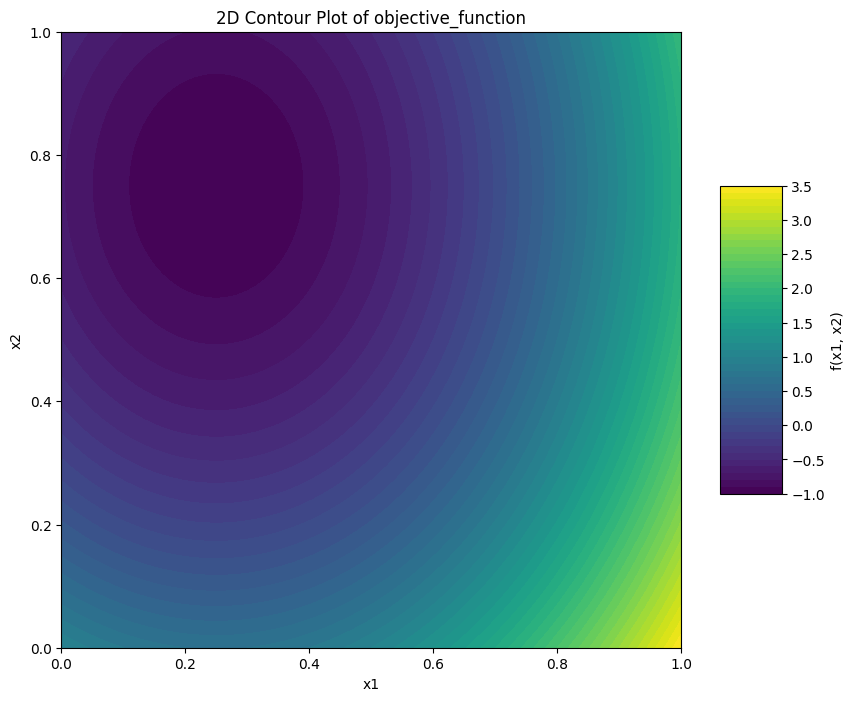

In [146]:
import numpy as np
import matplotlib.pyplot as plt

# Create a grid of x1 and x2 values within the unit box [0, 1]
x1_values = np.linspace(0, 1, 100)
x2_values = np.linspace(0, 1, 100)
X1, X2 = np.meshgrid(x1_values, x2_values)

# Prepare the input matrix for the objective_function
X_input_plot = np.column_stack((X1.ravel(), X2.ravel()))

# Calculate the objective function values for each point in the grid
Z = objective_function(X_input_plot).reshape(X1.shape)

# Optimal point - for this simple function, it's (0.25, 0.75) with value 0.0
X_opt = np.array([0.25, 0.75])
Z_opt = objective_function(np.array([[0.25, 0.75]])) # Pass as a 2D array

print(f"Optimal point: {X_opt}")
print(f"Optimal value: {Z_opt}")

# Create a 2D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

# Plot the filled contours
contour = ax.contourf(X1, X2, Z, levels=50, cmap='viridis')

# Add labels and title
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('2D Contour Plot of objective_function')

# Add a color bar which maps values to colors
fig.colorbar(contour, shrink=0.5, aspect=5, label='f(x1, x2)')

plt.show()

In [147]:
import numpy as np

X_initial = np.array([[0.5, 0.25], [0.5,0.75], [0.25, 0.5], [0.75, 0.5]]) # Initial points to observe
y_real = objective_function(X_initial)

y_noise = y_real + np.random.normal(0, 0.01, y_real.shape)

X = X_initial

print(y_real)
print(y_noise)

[ 0.0625 -0.6875 -0.8125  0.4375]
[ 0.07956571 -0.69676559 -0.82539957  0.42733938]


In [148]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

def get_next_best_point(X_observed: np.ndarray, y_observed_noise: np.ndarray, X_candidate_grid: np.ndarray) -> np.ndarray:
    """
    Calculates the next acquisition point using Gaussian Process Regression
    and Expected Improvement.

    Args:
        X_observed (np.ndarray): Observed data points (features), shape (n_samples, n_features).
        y_observed_noise (np.ndarray): Noisy observed values corresponding to X_observed, shape (n_samples,).
        X_candidate_grid (np.ndarray): A grid of candidate points for evaluation, shape (n_candidates, n_features).
        xi (float): Exploration-exploitation trade-off parameter. Higher xi encourages exploration.

    Returns:
        np.ndarray: The candidate point from X_candidate_grid with the maximum Expected Improvement.
    """

    # Initialize and fit the Gaussian Process Regressor
    kernel = ConstantKernel()* RBF(length_scale=1.0) + WhiteKernel()
    gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
    gpr.fit(X_observed, y_observed_noise)

    # Predict mean and standard deviation for the candidate points
    mu, sigma = gpr.predict(X_candidate_grid, return_std=True)
    y_min = np.min(y_observed_noise) # For minimization, we want the minimum observed value

    with np.errstate(divide='warn'):
        # Calculate improvement
        imp = y_min - mu # For minimization: f_min - mu
        Z = imp / sigma
        Z[sigma == 0.0] = 0.0 # Handle cases where sigma is zero to avoid division by zero

        # Calculate Expected Improvement
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0 # Ensure EI is 0 where there is no uncertainty

    # Find the point with the maximum Expected Improvement
    next_point_index = np.argmax(ei)
    next_acquisition_point = X_candidate_grid[next_point_index]

    return next_acquisition_point


In [149]:
X_next = get_next_acquisition_point(X, y_noise, X_mesh)
X_next

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


array([0., 0.])

In [150]:
y_next = objective_function(np.array([X_next])) + np.random.normal(0,0.1)
y_next

array([1.02299967])

In [151]:
X = np.vstack((X, np.array([X_next])))
y_noise = np.append(y_noise, y_next)

X, y_noise

(array([[0.5 , 0.25],
        [0.5 , 0.75],
        [0.25, 0.5 ],
        [0.75, 0.5 ],
        [0.  , 0.  ]]),
 array([ 0.07956571, -0.69676559, -0.82539957,  0.42733938,  1.02299967]))

In [152]:
for i in range(4):
  X_next = get_next_best_point(X, y_noise, X_mesh)
  y_next = objective_function(np.array([X_next])) + np.random.normal(0,0.1)

  X = np.vstack((X, np.array([X_next])))
  y_noise = np.append(y_noise, y_next)

In [153]:
X, y_noise

(array([[0.5       , 0.25      ],
        [0.5       , 0.75      ],
        [0.25      , 0.5       ],
        [0.75      , 0.5       ],
        [0.        , 0.        ],
        [0.25252525, 0.49494949],
        [0.27272727, 0.44444444],
        [0.17171717, 0.80808081],
        [0.24242424, 0.6969697 ]]),
 array([ 0.07956571, -0.69676559, -0.82539957,  0.42733938,  1.02299967,
        -0.87975824, -0.69519647, -0.97703359, -0.91948514]))

In [155]:
X_random = np.random.rand(5, 2)
X_random

array([[0.36110755, 0.6864557 ],
       [0.19426894, 0.22660865],
       [0.58312473, 0.32820921],
       [0.02003748, 0.28235452],
       [0.19586452, 0.61718591]])

In [157]:
y_noise_random = objective_function(X_random) + np.random.normal(0, 0.01, 5)
y_noise_random

array([-0.93246259, -0.15500374,  0.09925627, -0.07573413, -0.93381898])